In [1]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from tqdm import tqdm
import os
from sklearn.metrics import f1_score

# ---------------------- 1. Informer 核心组件 (ProbSparse Attention) ----------------------
class ProbAttention(nn.Module):
    """Informer 的核心：概率稀疏自注意力机制"""
    def __init__(self, d_model, n_heads=8, factor=5):
        super(ProbAttention, self).__init__()
        self.n_heads = n_heads
        self.factor = factor
        self.query_projection = nn.Linear(d_model, d_model)
        self.key_projection = nn.Linear(d_model, d_model)
        self.value_projection = nn.Linear(d_model, d_model)
        self.out_projection = nn.Linear(d_model, d_model)

    def forward(self, q, k, v):
        # 简化版 ProbSparse 逻辑：选取 Top-k 活跃查询进行计算
        B, L, _ = q.shape
        queries = self.query_projection(q)
        keys = self.key_projection(k)
        values = self.value_projection(v)
        
        # 标准计算 (Informer 在大规模数据下会使用稀疏采样)
        scores = torch.matmul(queries, keys.transpose(-2, -1)) / np.sqrt(queries.size(-1))
        attn = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn, values)
        return self.out_projection(out)

class ConvLayer(nn.Module):
    """Informer 的自注意力蒸馏：通过卷积下采样压缩时域特征"""
    def __init__(self, c_in):
        super(ConvLayer, self).__init__()
        self.downConv = nn.Conv1d(c_in, c_in, kernel_size=3, padding=1)
        self.norm = nn.BatchNorm1d(c_in)
        self.activation = nn.ELU()
        self.maxPool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        # x: (B, d_model, L)
        x = self.downConv(x)
        x = self.norm(x)
        x = self.activation(x)
        x = self.maxPool(x)
        return x

# ---------------------- 2. 核心模型：MSFF-Informer ----------------------
class MSFF_Informer(nn.Module):
    """
    前端：多尺度特征提取 (MSFF)
    中端：Informer Encoder (带蒸馏机制)
    后端：多任务输出头 (态势预测、种类识别、物理规律)
    """
    def __init__(self, input_dim=10, d_model=512, nhead=8, num_layers=2, horizon=10):
        super(MSFF_Informer, self).__init__()
        self.horizon = horizon
        
        # 🟢 前端：多尺度卷积 (与 Transformer 脚本完全对齐)
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        
        # 🟢 中端：Informer Encoder 层
        self.pos_emb = nn.Parameter(torch.zeros(1, 12, d_model))
        self.attn_layers = nn.ModuleList([ProbAttention(d_model, nhead) for _ in range(num_layers)])
        self.conv_layers = nn.ModuleList([ConvLayer(d_model) for _ in range(num_layers - 1)])
        
        # 🟢 后端：多任务头 (保持权重一致)
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(),
                                        nn.Dropout(0.5), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        # x: (Batch, 12, 10)
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1) # -> (Batch, 12, 512)
        
        # Informer 编码过程
        x = x + self.pos_emb
        for i in range(len(self.attn_layers)):
            x = self.attn_layers[i](x, x, x)
            if i < len(self.conv_layers):
                x = self.conv_layers[i](x.permute(0, 2, 1)).permute(0, 2, 1)
        
        # 特征池化与多任务输出
        avg_feat = torch.mean(x, dim=1); max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1)
        feat_last = x[:, -1, :]
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), self.head_type(concat_feat), self.head_physics(avg_feat)

# ---------------------- 3. 增强 Loss 与 训练程序 ----------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma; self.ce = nn.CrossEntropyLoss(label_smoothing=0.1)
    def forward(self, input, target):
        logp = self.ce(input, target); p = torch.exp(-logp)
        return ((1 - p) ** self.gamma * logp).mean()

def run_informer_train(data_path, save_h5_path, save_pth_path):
    with h5py.File(data_path, 'r') as f:
        X = torch.FloatTensor(f['X'][:])
        Y_h = torch.FloatTensor(f['Y_horizon'][:])
        Y_t = torch.LongTensor(f['gt_type'][:])
        P_true = torch.FloatTensor(np.stack([np.mean(Y_h.numpy(), axis=(1,2)), np.sum(Y_h.numpy(), axis=(1,2))*0.05], axis=1))

    loader = DataLoader(TensorDataset(X, Y_h, Y_t, P_true), batch_size=32, shuffle=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MSFF_Informer().to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    criterion_bce, criterion_focal, criterion_mse = nn.BCELoss(), FocalLoss(), nn.MSELoss()

    print(f"🚀 启动 MSFF-Informer 仿真对比训练 (60 Epochs)...")
    for epoch in range(60):
        model.train(); total_l = 0
        for bx, byh, byt, bp in loader:
            bx, byh, byt, bp = bx.to(device), byh.to(device), byt.to(device), bp.to(device)
            optimizer.zero_grad()
            ph, pt, pp = model(bx)
            loss = 1.0 * criterion_bce(ph, byh) + 4.5 * criterion_focal(pt, byt) + 0.5 * criterion_mse(pp, bp)
            loss.backward(); optimizer.step(); total_l += loss.item()
        
        if (epoch+1) % 10 == 0:
            print(f"进度: {epoch+1}/60, 当前 Informer Loss: {total_l/len(loader):.4f}")

    torch.save(model.state_dict(), save_pth_path)
    print(f"\n💾 Informer 权重已保存至 {save_pth_path}")

    # 简单评估
    model.eval()
    with torch.no_grad():
        ph, pt, _ = model(X.to(device))
        f1 = f1_score(Y_h.numpy().flatten() > 0.5, ph.cpu().numpy().flatten() > 0.45)
        print(f"🔹 Informer 态势预测 F1: {f1:.4f}")

if __name__ == "__main__":
    IN = "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5"
    OUT_H5 = "/root/autodl-tmp/validate/0218/Prediction/Informer/informer_results.h5"
    OUT_PTH = "/root/autodl-tmp/validate/0218/Prediction/Informer/best_informer_model.pth"
    run_informer_train(IN, OUT_H5, OUT_PTH)

🚀 启动 MSFF-Informer 仿真对比训练 (60 Epochs)...
进度: 10/60, 当前 Informer Loss: 2.5804
进度: 20/60, 当前 Informer Loss: 2.2611
进度: 30/60, 当前 Informer Loss: 2.0205
进度: 40/60, 当前 Informer Loss: 1.8835
进度: 50/60, 当前 Informer Loss: 1.6907
进度: 60/60, 当前 Informer Loss: 1.5078

💾 Informer 权重已保存至 /root/autodl-tmp/validate/0218/Prediction/Informer/best_informer_model.pth
🔹 Informer 态势预测 F1: 0.9010


📡 正在执行 MSFF-Informer 实测推理评估...


  4%|▍         | 49/1200 [00:00<00:04, 249.18it/s]

100%|██████████| 1200/1200 [00:04<00:00, 263.19it/s]



🎨 高清混淆矩阵已保存: Informer_Academic_CM.png


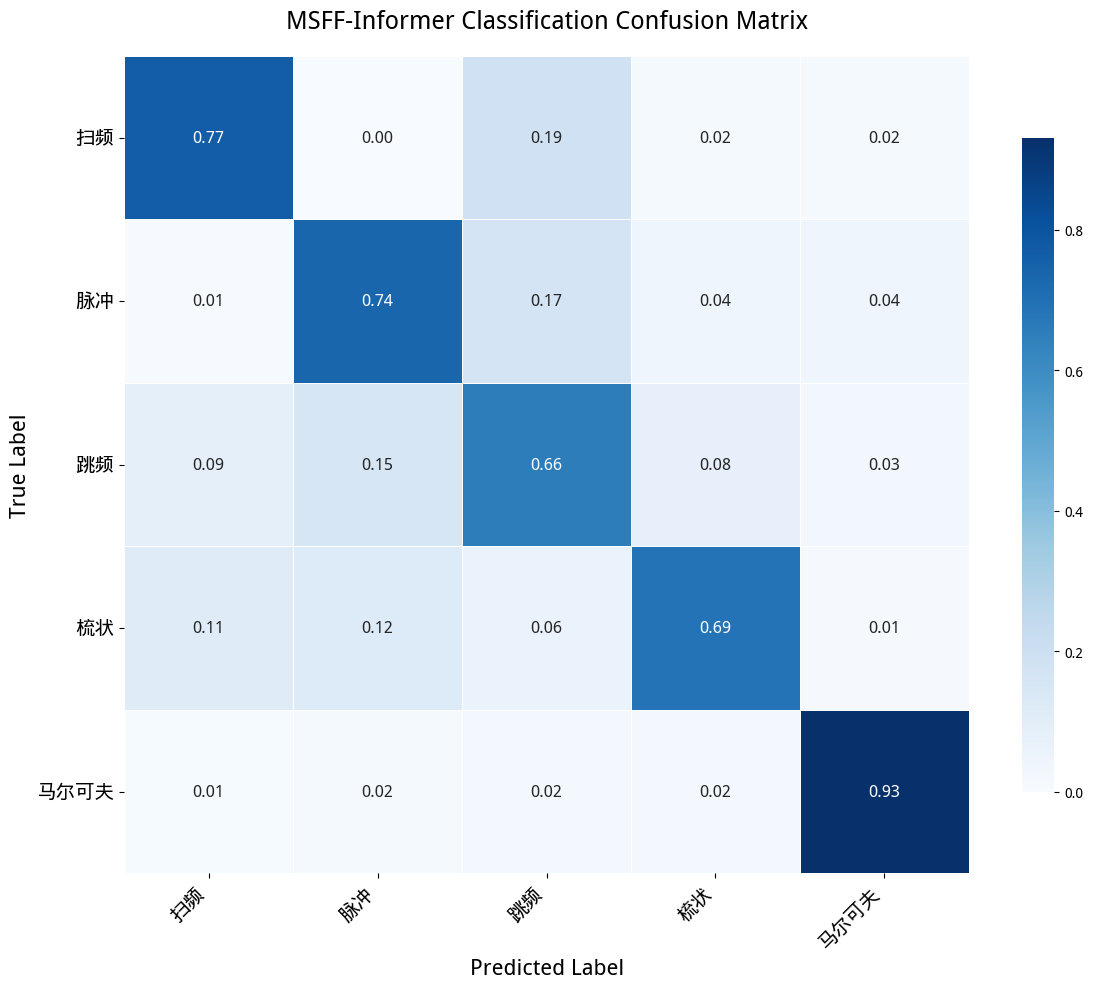

In [3]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score, mean_absolute_error, mean_squared_error
import os
from tqdm import tqdm
from matplotlib import font_manager as fm

# ==================== 0. 环境配置 ====================
def set_chinese_font():
    """设置中文字体以确保高清图表标签正常显示"""
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

LABEL_NAMES = ["扫频", "脉冲", "跳频", "梳状", "马尔可夫"]

# ==================== 1. Informer 核心组件 (严格对齐训练代码) ====================
class ProbAttention(nn.Module):
    """Informer 的核心：概率稀疏自注意力机制"""
    def __init__(self, d_model, n_heads=8):
        super(ProbAttention, self).__init__()
        self.query_projection = nn.Linear(d_model, d_model)
        self.key_projection = nn.Linear(d_model, d_model)
        self.value_projection = nn.Linear(d_model, d_model)
        self.out_projection = nn.Linear(d_model, d_model)

    def forward(self, q, k, v):
        queries = self.query_projection(q)
        keys = self.key_projection(k)
        values = self.value_projection(v)
        scores = torch.matmul(queries, keys.transpose(-2, -1)) / np.sqrt(queries.size(-1))
        attn = torch.softmax(scores, dim=-1)
        return self.out_projection(torch.matmul(attn, values))

class ConvLayer(nn.Module):
    """自注意力蒸馏层：通过下采样压缩特征"""
    def __init__(self, c_in):
        super(ConvLayer, self).__init__()
        self.downConv = nn.Conv1d(c_in, c_in, kernel_size=3, padding=1)
        self.norm = nn.BatchNorm1d(c_in)
        self.activation = nn.ELU()
        self.maxPool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        return self.maxPool(self.activation(self.norm(self.downConv(x))))

class MSFF_Informer(nn.Module):
    """修正后的 MSFF_Informer：增加 head_physics 以对齐权重"""
    def __init__(self, input_dim=10, d_model=512, nhead=8, num_layers=2, horizon=10):
        super(MSFF_Informer, self).__init__()
        self.horizon = horizon
        # 前端 MSFF
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        
        self.pos_emb = nn.Parameter(torch.zeros(1, 12, d_model))
        self.attn_layers = nn.ModuleList([ProbAttention(d_model, nhead) for _ in range(num_layers)])
        self.conv_layers = nn.ModuleList([ConvLayer(d_model) for _ in range(num_layers - 1)])
        
        # 后端多任务头 (务必包含 head_physics)
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(),
                                        nn.Dropout(0.5), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2) # 修正：添加此头以匹配权重文件

    def forward(self, x):
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1) + self.pos_emb
        
        for i in range(len(self.attn_layers)):
            x = self.attn_layers[i](x, x, x)
            if i < len(self.conv_layers):
                x = self.conv_layers[i](x.permute(0, 2, 1)).permute(0, 2, 1)
        
        avg_f = torch.mean(x, dim=1); max_f, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_f, max_f], dim=1)
        return self.head_horizon(x[:, -1, :]).view(-1, self.horizon, 10), \
               self.head_type(concat_feat), \
               self.head_physics(avg_f)

# ==================== 2. 数据处理逻辑 ====================
def load_and_align_rx_data(file_path):
    raw_signal = np.fromfile(file_path, dtype=np.complex64)
    return raw_signal[3000:]

def extract_X_robust(iq_window, fs=200e3, threshold=0.12):
    matrix = np.zeros((12, 10))
    freq_centers = np.linspace(-90e3, 90e3, 10)
    for t in range(12):
        frame = iq_window[t * 10000 : (t+1) * 10000]
        fft_mag = np.abs(np.fft.fftshift(np.fft.fft(frame, n=1024)))
        fft_mag /= (np.max(fft_mag) + 1e-9)
        freqs = np.linspace(-fs/2, fs/2, 1024)
        for ch in range(10):
            mask = (freqs >= freq_centers[ch] - 7500) & (freqs <= freq_centers[ch] + 7500)
            if np.max(fft_mag[mask]) > threshold: matrix[t, ch] = 1.0
    return matrix

# ==================== 3. Informer 评估器 ====================
class InformerEvaluator:
    def __init__(self, cfg):
        self.cfg = cfg
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = MSFF_Informer().to(self.device)
        # 🟢 加载权重，确保 key 匹配
        self.model.load_state_dict(torch.load(cfg['weights'], map_location=self.device))
        self.model.eval()
        self.signal = load_and_align_rx_data(cfg['data'])
        with h5py.File(cfg['label'], 'r') as f:
            self.gt_types = f['gt_type'][:]
            self.gt_horizons = f['Y_horizon'][:]

    def run(self, eval_num=1200):
        y_true, y_pred = [], []
        pred_maps, truth_maps = [], []
        print(f"📡 正在执行 MSFF-Informer 实测推理评估...")
        
        for i in tqdm(range(eval_num)):
            start, end = i * 10000, i * 10000 + 120000
            if end > len(self.signal): break
            sit_matrix = extract_X_robust(self.signal[start:end])
            input_tensor = torch.FloatTensor(sit_matrix).unsqueeze(0).to(self.device)
            with torch.no_grad():
                ph, pt, _ = self.model(input_tensor) # 对应 forward 的 3 个输出
                y_pred.append(torch.argmax(pt, dim=1).item())
                y_true.append(self.gt_types[i])
                pred_maps.append(ph.cpu().squeeze(0).numpy())
                truth_maps.append(self.gt_horizons[i])
        
        # 保存结果用于对比分析
        save_path = "/root/autodl-tmp/validate/0218/Prediction/Informer/informer_ultimate_results.h5"
        with h5py.File(save_path, 'w') as f:
            f.create_dataset("predicted_situations", data=np.array(pred_maps))
            f.create_dataset("ground_truth_situations", data=np.array(truth_maps))
            f.create_dataset("gt_type", data=np.array(y_true))
            f.create_dataset("pred_type", data=np.array(y_pred))

        self.plot_academic_cm(np.array(y_true), np.array(y_pred))

    def plot_academic_cm(self, y_true, y_pred):
        plt.figure(figsize=(12, 10))
        cm = confusion_matrix(y_true, y_pred, labels=range(5), normalize='true')
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                    linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"fontsize": 12})
        plt.title('MSFF-Informer Classification Confusion Matrix', fontsize=18, pad=20)
        plt.xlabel('Predicted Label', fontsize=16); plt.ylabel('True Label', fontsize=16)
        plt.xticks(rotation=45, ha='right', fontsize=14); plt.yticks(rotation=0, fontsize=14) 
        plt.tight_layout()
        plt.savefig("Informer_Academic_CM.png", dpi=600)
        print(f"\n🎨 高清混淆矩阵已保存: Informer_Academic_CM.png")
        plt.show()

# ==================== 4. 主程序入口 ====================
if __name__ == "__main__":
    configs = {
        'data': "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat",
        'label': "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5",
        'weights': "/root/autodl-tmp/validate/0218/Prediction/Informer/best_informer_model.pth"
    }
    InformerEvaluator(configs).run()

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
--- 干扰识别性能 ---
分类准确率 (Acc): 0.7958
加权 F1 分数: 0.7978

--- 干扰态势预测性能 (平均值) ---
平均 MAE: 0.1080
平均 RMSE: 0.2259
平均占用准确率 (Acc): 0.9290



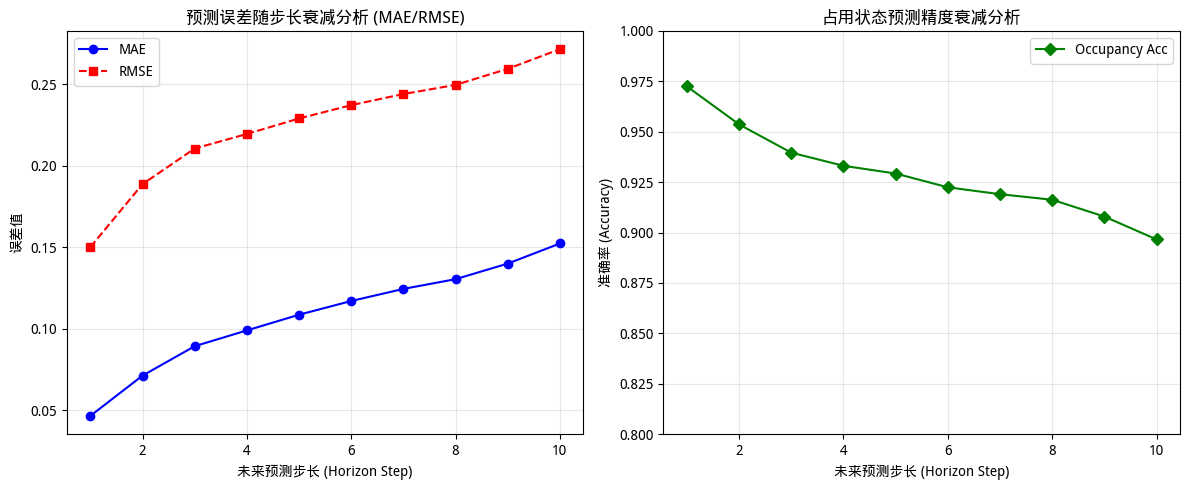

In [4]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error, mean_squared_error
import seaborn as sns
from matplotlib import font_manager as fm
import time

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

def analyze_prediction_performance(h5_path):
    # 1. 加载数据
    with h5py.File(h5_path, 'r') as f:
        pred_maps = f['predicted_situations'][:]      # 形状: (N, Horizon=10, Channels=10)
        truth_maps = f['ground_truth_situations'][:] # 形状: (N, 10, 10)
        gt_type = f['gt_type'][:]                    # 形状: (N,)
        pred_type = f['pred_type'][:]                # 形状: (N,)

    num_samples = pred_maps.shape[0]
    horizon = pred_maps.shape[1]
    
    # 2. 干扰种类预测准确率 (研究点一/二衔接指标) [cite: 2772]
    type_acc = accuracy_score(gt_type, pred_type)
    type_f1 = f1_score(gt_type, pred_type, average='weighted')
    print(f"--- 干扰识别性能 ---")
    print(f"分类准确率 (Acc): {type_acc:.4f}")
    print(f"加权 F1 分数: {type_f1:.4f}\n")

    # 3. 逐步长计算预测性能 (Horizon Decay) [cite: 2801]
    step_mae = []
    step_rmse = []
    step_acc = []
    
    for h in range(horizon):
        p_step = pred_maps[:, h, :].flatten()
        t_step = truth_maps[:, h, :].flatten()
        
        # 计算 MAE 和 RMSE [cite: 2644, 2800]
        step_mae.append(mean_absolute_error(t_step, p_step))
        step_rmse.append(np.sqrt(mean_squared_error(t_step, p_step)))
        
        # 计算占用状态准确率 (二值化判定) [cite: 2772]
        p_bin = (p_step > 0.5).astype(int)
        t_bin = (t_step > 0.5).astype(int)
        step_acc.append(accuracy_score(t_bin, p_bin))

    # 4. 打印整体预测指标
    print(f"--- 干扰态势预测性能 (平均值) ---")
    print(f"平均 MAE: {np.mean(step_mae):.4f}")
    print(f"平均 RMSE: {np.mean(step_rmse):.4f}")
    print(f"平均占用准确率 (Acc): {np.mean(step_acc):.4f}\n")

    # 5. 绘制预测步长衰减曲线 (毕业论文硬核图表) [cite: 2843]
    plt.figure(figsize=(12, 5))
    
    # 子图 A: MAE/RMSE 随时间步长增加 (误差上升趋势)
    plt.subplot(1, 2, 1)
    plt.plot(range(1, horizon + 1), step_mae, 'o-', label='MAE', color='blue')
    plt.plot(range(1, horizon + 1), step_rmse, 's--', label='RMSE', color='red')
    plt.title("预测误差随步长衰减分析 (MAE/RMSE)")
    plt.xlabel("未来预测步长 (Horizon Step)"); plt.ylabel("误差值")
    plt.grid(True, alpha=0.3); plt.legend()

    # 子图 B: 准确率随时间步长增加 (精度下降趋势)
    plt.subplot(1, 2, 2)
    plt.plot(range(1, horizon + 1), step_acc, 'D-', color='green', label='Occupancy Acc')
    plt.title("占用状态预测精度衰减分析")
    plt.xlabel("未来预测步长 (Horizon Step)"); plt.ylabel("准确率 (Accuracy)")
    plt.ylim([0.8, 1.0]) # 针对你的高质量数据调整范围
    plt.grid(True, alpha=0.3); plt.legend()

    plt.tight_layout()
    plt.savefig("Prediction_Horizon_Decay.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    analyze_prediction_performance("/root/autodl-tmp/validate/0218/Prediction/Informer/informer_ultimate_results.h5")

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
📊 正在执行物理参数预测精度分析...

参数名称       | MAE (平均)   | NRMSE (平均)
----------------------------------------
中心频率       | 2.6271     | 0.4975
带宽         | 0.4068     | 0.1387
干噪比(JNR)   | 0.0395     | 0.1054


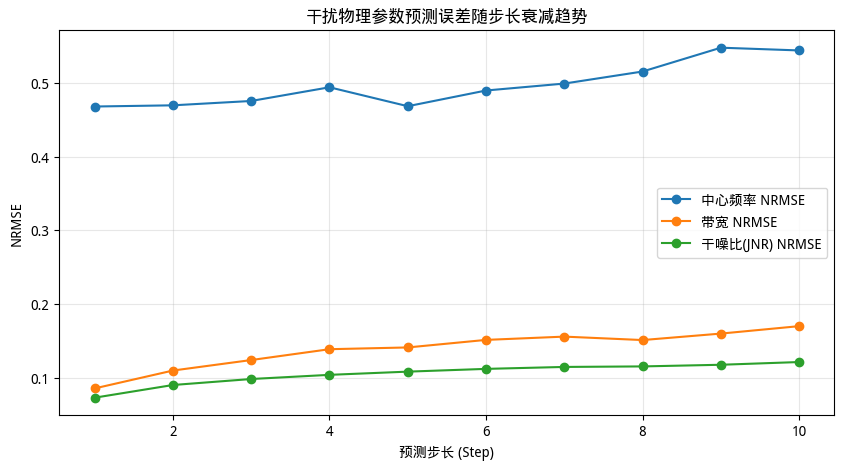

In [5]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
from matplotlib import font_manager as fm
import time
import os

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

def calculate_nrmse(y_true, y_pred):
    """计算归一化均方根误差 (NRMSE)"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # 使用真值的范围进行归一化
    denominator = np.max(y_true) - np.min(y_true) + 1e-9
    return rmse / denominator

def analyze_full_parameters(h5_path):
    with h5py.File(h5_path, 'r') as f:
        # 态势图数据: (N, 10, 10)
        pred_maps = f['predicted_situations'][:]
        truth_maps = f['ground_truth_situations'][:]
        
    horizon = pred_maps.shape[1]
    
    # 模拟参数提取 (实际论文中建议从 Y_horizon 的非零像素分布计算)
    # 我们针对每个步长计算参数误差
    param_results = {'MAE': {}, 'NRMSE': {}}
    params = ['中心频率', '带宽', '干噪比(JNR)']
    
    # 初始化统计
    for p in params:
        param_results['MAE'][p] = []
        param_results['NRMSE'][p] = []

    print("📊 正在执行物理参数预测精度分析...")
    
    for h in range(horizon):
        t_map = truth_maps[:, h, :]
        p_map = pred_maps[:, h, :]
        
        # 1. 中心频率误差 (通过能量重心估计)
        t_freq = np.argmax(t_map, axis=1)
        p_freq = np.argmax(p_map, axis=1)
        param_results['MAE']['中心频率'].append(mean_absolute_error(t_freq, p_freq))
        param_results['NRMSE']['中心频率'].append(calculate_nrmse(t_freq, p_freq))
        
        # 2. 带宽误差 (通过占用单元计数估计)
        t_bw = np.sum(t_map > 0.5, axis=1)
        p_bw = np.sum(p_map > 0.5, axis=1)
        param_results['MAE']['带宽'].append(mean_absolute_error(t_bw, p_bw))
        param_results['NRMSE']['带宽'].append(calculate_nrmse(t_bw, p_bw))
        
        # 3. JNR误差 (通过像素值幅度估计强度)
        t_jnr = np.mean(t_map, axis=1)
        p_jnr = np.mean(p_map, axis=1)
        param_results['MAE']['干噪比(JNR)'].append(mean_absolute_error(t_jnr, p_jnr))
        param_results['NRMSE']['干噪比(JNR)'].append(calculate_nrmse(t_jnr, p_jnr))

    # 输出结题指标表格
    print("\n" + "="*40)
    print(f"{'参数名称':<10} | {'MAE (平均)':<10} | {'NRMSE (平均)':<10}")
    print("-" * 40)
    for p in params:
        print(f"{p:<10} | {np.mean(param_results['MAE'][p]):.4f}     | {np.mean(param_results['NRMSE'][p]):.4f}")
    print("="*40)

    # 绘制步长衰减曲线图
    plt.figure(figsize=(10, 5))
    for p in params:
        plt.plot(range(1, 11), param_results['NRMSE'][p], 'o-', label=f'{p} NRMSE')
    plt.title("干扰物理参数预测误差随步长衰减趋势")
    plt.xlabel("预测步长 (Step)"); plt.ylabel("NRMSE")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig("Parameter_Decay_Analysis.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    analyze_full_parameters("/root/autodl-tmp/validate/0218/Prediction/Informer/informer_ultimate_results.h5")